#### Test plotting functions using the H2H2 data.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Check energy conservation

datafile = "data/O2O2_collisions_uniform.npy"
mdn_path = "results/models/mdn_O2O2.pth"

if ".npy" in datafile:
    data = np.load(datafile)
    data = pd.DataFrame(data, columns=["Etr", "Er1", "Er2", "Etrp", "Er1p", "Er2p"])
elif ".csv" in datafile:
    data = pd.read_csv(datafile, skiprows=1)
else:
    raise ValueError("Unsupported file format. Please provide a .csv or .npy file.")

Etot_init = data.iloc[:,0] + data.iloc[:,1] + data.iloc[:,2]
Etot_final = data.iloc[:,3] + data.iloc[:,4] + data.iloc[:,5]
print(f"Total energy before collisions: {Etot_init.sum():.6e} J")
print(f"Total energy after collisions: {Etot_final.sum():.6e} J")
print(f"Total Energy difference: {Etot_final.sum() - Etot_init.sum():.6e} J")
print(f"Relative Energy difference: {100 * (Etot_final.sum() - Etot_init.sum()) / Etot_init.sum():.6e} %")

Total energy before collisions: 3.219143e+09 J
Total energy after collisions: 3.219139e+09 J
Total Energy difference: -4.126565e+03 J
Relative Energy difference: -1.281883e-04 %


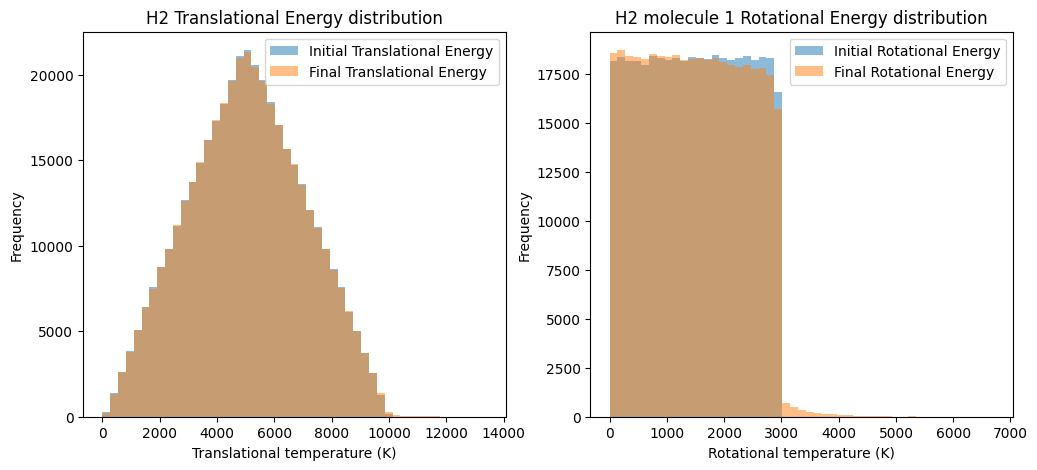

In [7]:
fig, ax= plt.subplots(1, 2, figsize=(12, 5))
# Plot translational energy distribution
bins = np.linspace(0, max(data.iloc[:,0].max(), data.iloc[:,3].max()), 50)
Etr_init = data.iloc[:,0]
Etr_final = data.iloc[:,3]
ax[0].hist(Etr_init, bins=bins, alpha=0.5, label='Initial Translational Energy')
ax[0].hist(Etr_final, bins=bins, alpha=0.5, label='Final Translational Energy')
ax[0].set_xlabel('Translational temperature (K)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('H2 Translational Energy distribution')
ax[0].legend()

# Plot rotational energy distribution
bins = np.linspace(0, max(data.iloc[:,1].max(), data.iloc[:,4].max()), 50)
Er1_init = data.iloc[:,1]
Er1_final = data.iloc[:,4]
ax[1].hist(Er1_init, bins=bins, alpha=0.5, label='Initial Rotational Energy')
ax[1].hist(Er1_final, bins=bins, alpha=0.5, label='Final Rotational Energy')
ax[1].set_xlabel('Rotational temperature (K)')
ax[1].set_ylabel('Frequency')
ax[1].set_title('H2 molecule 1 Rotational Energy distribution')
ax[1].legend()
plt.show()

This indicates the energy distribution nudges toward equilibrium over many collisions.

In [8]:
import torch
from utils.helpers import load_dataset
from machinelearning.mdn import MixtureDensityNetwork
from machinelearning.gmm import GaussianMixtureModel
from config.experiment_config import ExperimentConfig
config = ExperimentConfig()

data = load_dataset(datafile, rows=config.num_samples)

# Sample MDN
mdn = MixtureDensityNetwork(input_dim=config.input_dim, output_dim=config.output_dim, num_mixtures=config.num_mixtures, hidden_dim=config.hidden_dim, randomseed=config.random_seed) 
mdn.load_model(mdn_path)
torch.manual_seed(config.random_seed)
mdn_samples = mdn.sample(x=data[0])

# Sample GMM
gmm = GaussianMixtureModel(n_components=config.gmm_n_components, covariance_type=config.gmm_covariance_type)
gmm.fit(data[1])
gmm_samples = gmm.sample(num_samples=config.num_samples)

datasets = {
    "inputs": data[0][:,1:], # Use only the energy fractions for plotting not the total energy
    "CTC": data[1],
    "MDN": mdn_samples,
    # "GMM": gmm_samples
}

Dataset contains 30000 rows


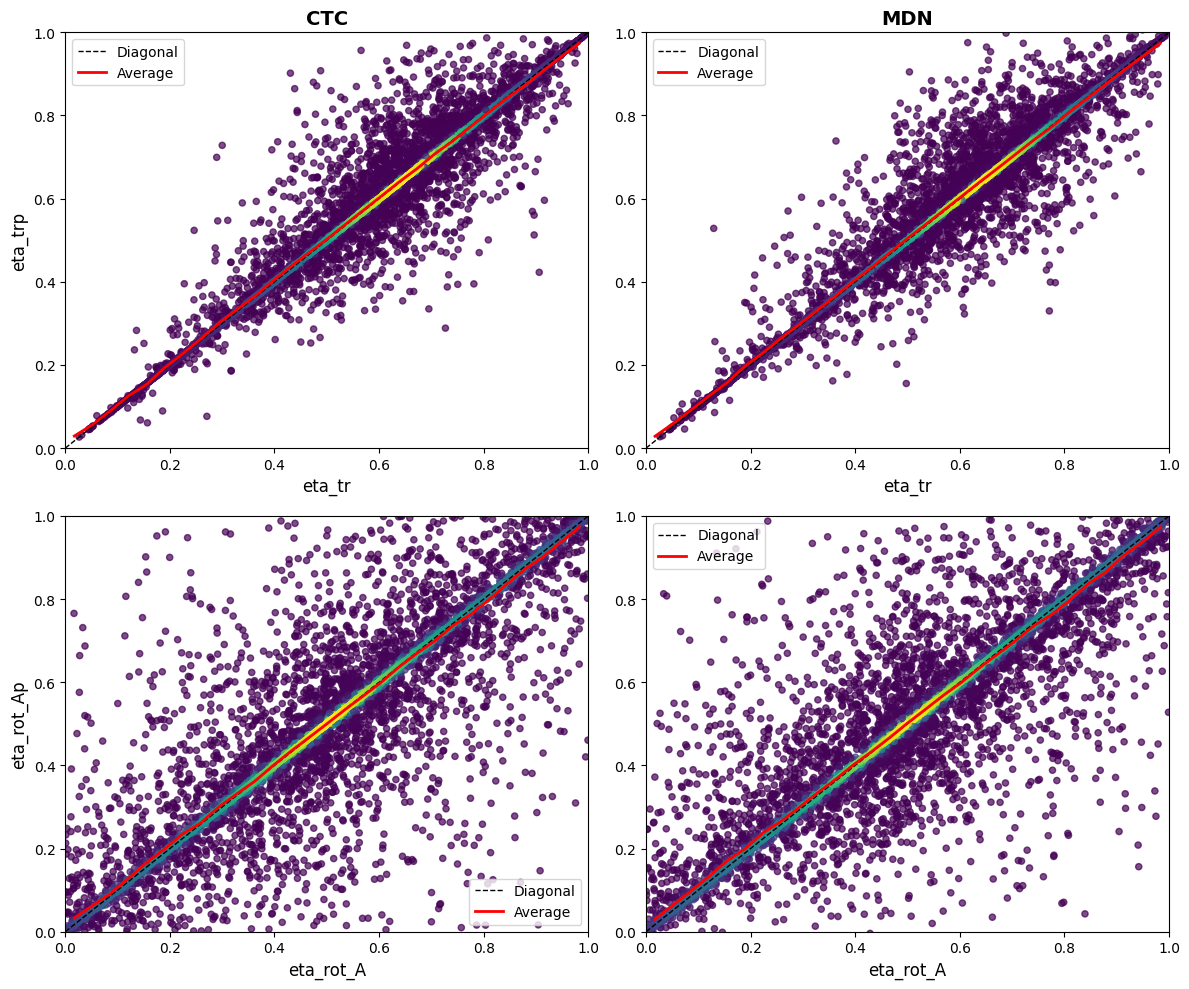

In [9]:
from visualization.plot import plot_density_scatter
from config.plotting_config import PlottingConfig
plotting_config = PlottingConfig()

# Create scatterplot
figsize_x = plotting_config.figsize[0] * 2
figsize_y = plotting_config.figsize[1] * 2
fig, ax = plt.subplots(2, 2, figsize=(figsize_x, figsize_y))
plot_density_scatter(ax, datasets=datasets)

datasetnames = list(datasets.keys())
datasetnames.remove("inputs")

eta_labels = ["eta_tr", "eta_rot_A"]
n = 30
for i in range(2):
    x = datasets["inputs"][:, i]
    for j, dataset_name in enumerate(datasetnames):
        y = datasets[dataset_name][:, i]

        # Plot diagonal
        ax[i, j].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Diagonal')

        # Bin the x-axis and compute means
        bins = np.linspace(0, 1, n)
        bin_indices = np.digitize(x, bins)
        bin_means = np.array([y[bin_indices == k].mean() for k in range(1, len(bins))])
        bin_centers = (bins[:-1] + bins[1:]) / 2

        # Plot a line connecting binned averages
        ax[i, j].plot(bin_centers, bin_means, color='red', label='Average', linewidth=2)
        ax[i, j].legend()

        # Find crossing with diagonal (bin_means - bin_centers changes sign)
        # Filter NaN bins first (empty bins return nan from .mean())
        x_crossings = []
        valid = ~np.isnan(bin_means)
        valid_centers = bin_centers[valid]
        valid_means = bin_means[valid]
        diff = valid_means - valid_centers
        sign_changes = np.where(np.diff(np.sign(diff)))[0]
        for idx in sign_changes:
            x0, x1 = valid_centers[idx], valid_centers[idx + 1]
            d0, d1 = diff[idx], diff[idx + 1]
            x_cross = x0 - d0 * (x1 - x0) / (d1 - d0)
            x_crossings.append(x_cross)

        # if x_crossings:
        #     avg_x_cross = float(np.mean(x_crossings))
        #     print(f"{dataset_name}, {eta_labels[i]}: average crossover with diagonal at x = {avg_x_cross:.4f}")
        # else:
        #     print(f"{dataset_name}, {eta_labels[i]}: no crossover with diagonal detected")

        ax[i, j].set_xlim(0, 1)
        ax[i, j].set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [10]:
from analysis.kl_divergence import kl_divergence

kl_ctc_mdn_tr  = kl_divergence(datasets["CTC"][:, 0], datasets["MDN"][:, 0])
kl_ctc_mdn_rot = kl_divergence(datasets["CTC"][:, 1], datasets["MDN"][:, 1])

print(f"KL Divergence (eta_tr):    {kl_ctc_mdn_tr:.4f}")
print(f"KL Divergence (eta_rot_A): {kl_ctc_mdn_rot:.4f}")

KL Divergence (eta_tr):    0.0006
KL Divergence (eta_rot_A): 0.0013
